In [20]:
from tsai.all import *
my_setup()

os              : Linux-6.8.0-111-generic-x86_64-with-glibc2.35
python          : 3.10.0
tsai            : 1.0.1
fastai          : 2.8.7
fastcore        : 1.13.2
torch           : 2.12.0+cpu
device          : cpu
cpu cores       : 2
threads per cpu : 1
RAM             : 11.57 GB
GPU memory      : N/A


In [18]:
import pandas as pd
from helper_function import get_kss_score, apply_fixed_scaling

df = pd.read_csv("data_val/25116_2_4_4/mmwave_ss.csv")
df["log_time"] = pd.to_datetime(df['log_time'])
df = df.set_index("log_time")
df = df.resample("1s").mean().interpolate(method="linear").dropna()
df = df.reset_index()
df["kss"] = get_kss_score("data_val/25116_2_4_4/mmwave_ss.csv")
df["kss"] = apply_fixed_scaling(df["kss"], 1, 9)
df["breath_rate"] = apply_fixed_scaling(df["breath_rate"], 5, 40)
df["heart_rate"] = apply_fixed_scaling(df["heart_rate"], 40, 200)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1214 entries, 0 to 1213
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   log_time     1214 non-null   datetime64[ns]
 1   heart_rate   1214 non-null   float64       
 2   breath_rate  1214 non-null   float64       
 3   kss          1214 non-null   float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 38.1 KB


In [53]:
X = df[["breath_rate", "heart_rate"]]
Y = df[["kss"]]
X.info(), Y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1214 entries, 0 to 1213
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   breath_rate  1214 non-null   float64
 1   heart_rate   1214 non-null   float64
dtypes: float64(2)
memory usage: 19.1 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1214 entries, 0 to 1213
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   kss     1214 non-null   float64
dtypes: float64(1)
memory usage: 9.6 KB


(None, None)

In [62]:
# create sliding windows to make (batch, features, n_data_points)
X_sliding, _ = apply_sliding_window(X, window_len=10, horizon=10)
_, Y_sliding = apply_sliding_window(Y, window_len=10, horizon=10)
X_sliding.shape, Y_sliding.shape, X_sliding[:1], Y_sliding[:1]

((1195, 2, 10),
 (1195,),
 array([[[0.34285714, 0.28571429, 0.2       , 0.17142857, 0.14285714,
          0.1125    , 0.10714286, 0.10178571, 0.09464286, 0.08928571],
         [0.25625   , 0.24375   , 0.23125   , 0.21875   , 0.209375  ,
          0.196875  , 0.19375   , 0.203125  , 0.225     , 0.23125   ]]]),
 array([0.375]))

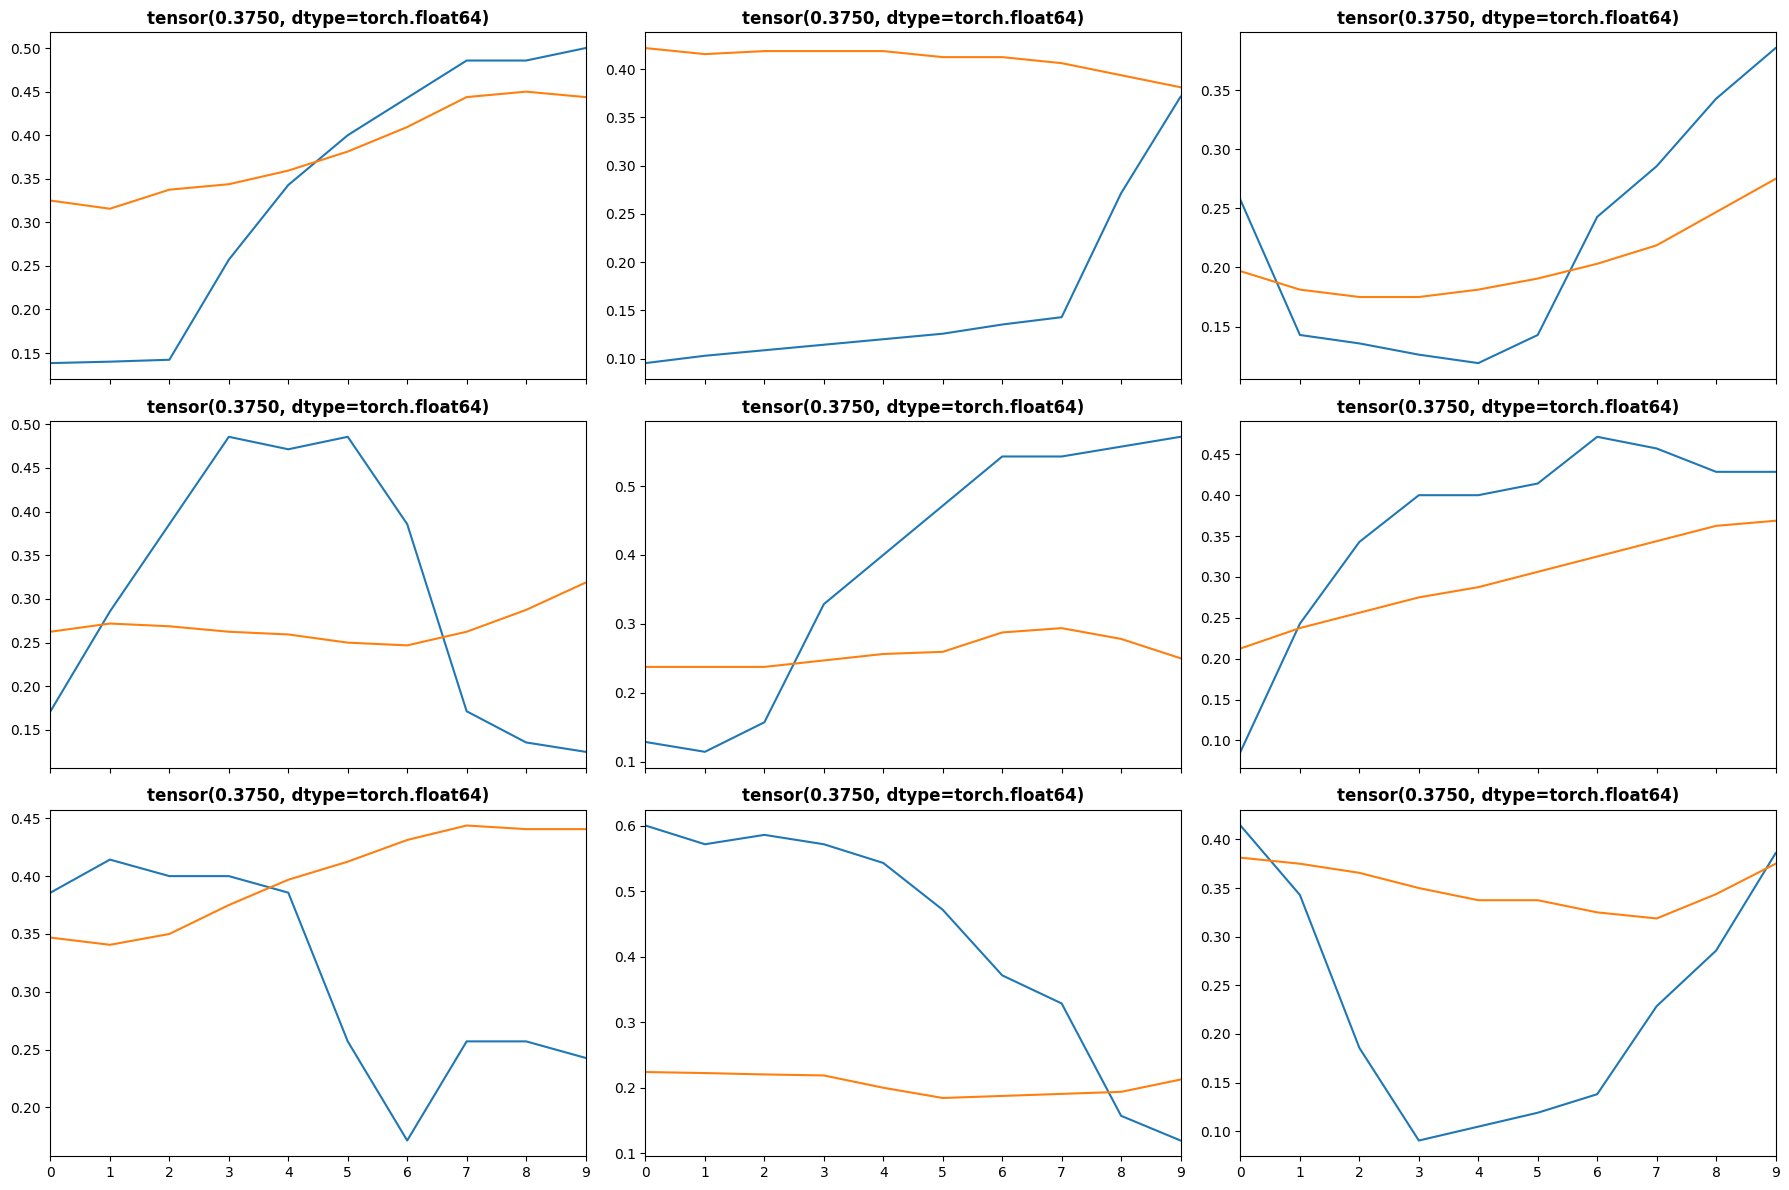

In [63]:
data_loader = get_ts_dls(X_sliding, Y_sliding, bs=128)
data_loader.show_batch()

<div><table class="fastprogress"><thead><tr><th>epoch</th><th>train_loss</th><th>mae</th><th>_rmse</th><th>time</th></tr></thead><tbody><tr><td>0</td><td>0.064763</td><td>00:12</td></tr><tr><td>1</td><td>0.036644</td><td>00:05</td></tr><tr><td>2</td><td>0.024411</td><td>00:05</td></tr><tr><td>3</td><td>0.017460</td><td>00:06</td></tr><tr><td>4</td><td>0.013092</td><td>00:07</td></tr><tr><td>5</td><td>0.010087</td><td>00:07</td></tr><tr><td>6</td><td>0.007865</td><td>00:05</td></tr><tr><td>7</td><td>0.006272</td><td>00:04</td></tr><tr><td>8</td><td>0.005057</td><td>00:05</td></tr><tr><td>9</td><td>0.004120</td><td>00:05</td></tr></tbody></table></div>

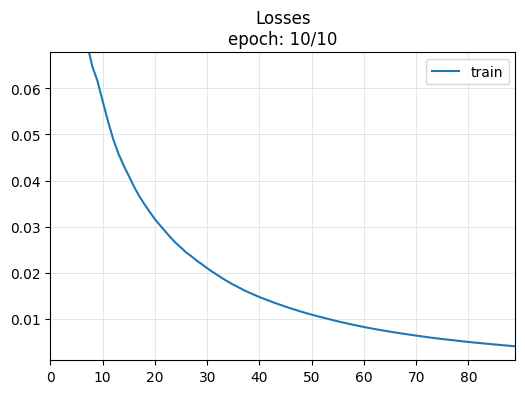

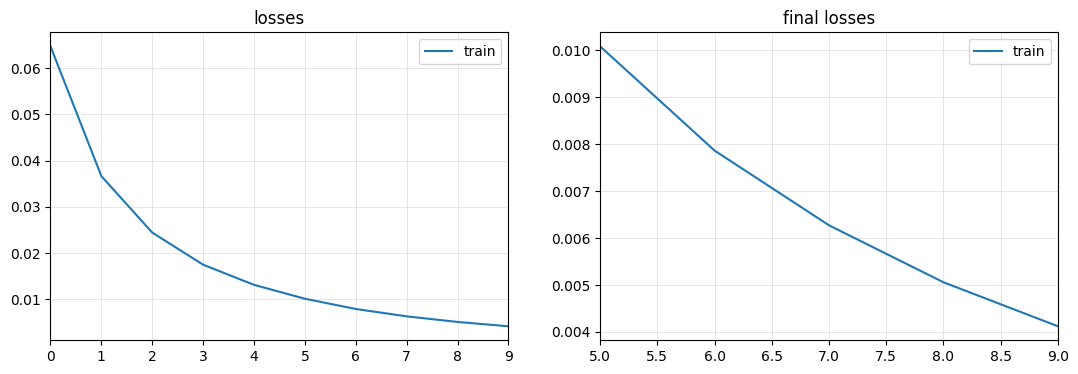

In [74]:
learner = ts_learner(data_loader, InceptionTime, metrics=[mae, rmse], cbs=ShowGraph())
learner.fit_one_cycle(10, 1e-3)

FlattenedLoss of MSELoss()